# 🛡️ Explainable Toxicity Classifier — Responsible AI Pipeline
**Course:** Responsible AI | **Stack:** Detoxify · LIME · SHAP · TextAttack · Gradio

| Phase | Task | Key Concept |
|-------|------|-------------|
| 1 | Environment Setup | Dependencies |
| 2 | Baseline Inference | Pre-trained toxic-bert |
| 3-A | LIME Explanations | Local word importance |
| 3-B | SHAP Explanations | Shapley token attribution |
| 3-C | AOPC Faithfulness | Which XAI is more trustworthy? |
| 4 | Adversarial Red-Teaming | ASR per attack type |
| 5 | HITL Dashboard | Gradio + feedback logging |
| 6 | Robust Fine-Tuning | Weighted BCE + combined dataset |
| 7 | Final Evaluation | Baseline vs hardened model |


---
## Phase 1 — Environment Setup
> **GPU tip (Colab):** Runtime → Change runtime type → T4 GPU


In [1]:
!pip install transformers torch shap lime textattack gradio \
           datasets scikit-learn matplotlib seaborn nltk accelerate -q

import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('✅ All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 78.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 90.2 MB/s eta 0:00:

---
## Phase 2 — Baseline Model Inference

`unitary/toxic-bert` outputs **6 independent probabilities** (multi-label):

| Label | Meaning |
|-------|---------|
| `toxic` | General toxicity |
| `severe_toxic` | Extreme/hateful |
| `obscene` | Sexually explicit |
| `threat` | Direct violence threat |
| `insult` | Personal insults |
| `identity_hate` | Identity-based hate speech |

> **Why `return_all_scores=True`?**
> Multi-label: a comment can be both `toxic` AND `insult` at the same time.
> Without this flag the pipeline returns only the top-scoring label, losing the rest.


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, os, csv

MODEL_NAME = 'unitary/toxic-bert'
LABEL_COLS = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
DEVICE     = 0 if torch.cuda.is_available() else -1
THRESHOLD  = 0.5
print(f"Device: {'GPU' if DEVICE==0 else 'CPU'}")

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

classifier = pipeline(
    'text-classification',
    model=base_model, tokenizer=tokenizer,
    device=DEVICE, return_all_scores=True,
)
print(f'Loaded: {MODEL_NAME}')

Device: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Device set to use cuda:0


Loaded: unitary/toxic-bert


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [3]:
def get_scores(text):
    """Return {label: score} for all 6 Jigsaw labels."""
    return {item['label']: item['score'] for item in classifier(text)[0]}

test_cases = [
    ('Clean',       'I completely disagree with your thoughtful assessment.'),
    ('Toxic',       'You are an absolute idiot for thinking this would work.'),
    ('Adversarial', 'You are an absolute nincompoop for thinking this would work.'),
    ('Threat',      'I will end you if you say that again.'),
    ('Identity',    'People from that religion are all criminals.'),
]
print(f"{'Type':<14} {'toxic':>7} {'insult':>8} {'threat':>8}  Text")
print('-'*90)
for lbl, text in test_cases:
    s    = get_scores(text)
    flag = '🚩' if s.get('toxic',0) > THRESHOLD else '✅'
    print(f"{flag} {lbl:<12} {s.get('toxic',0):7.4f} {s.get('insult',0):8.4f} "
          f"{s.get('threat',0):8.4f}  {text[:60]}")

Type             toxic   insult   threat  Text
------------------------------------------------------------------------------------------
✅ Clean         0.0006   0.0002   0.0001  I completely disagree with your thoughtful assessment.
🚩 Toxic         0.9817   0.9357   0.0013  You are an absolute idiot for thinking this would work.
✅ Adversarial   0.2512   0.0382   0.0005  You are an absolute nincompoop for thinking this would work.
✅ Threat        0.3873   0.0078   0.2906  I will end you if you say that again.
✅ Identity      0.1929   0.0078   0.0021  People from that religion are all criminals.


---
## Phase 3-A — LIME (Local Interpretable Model-Agnostic Explanations)

**Algorithm:**
1. Split text into word tokens
2. Create ~500 **perturbed** versions by randomly masking words
3. Feed all versions through the model → get predictions
4. Fit a **linear surrogate** on (mask, prediction) pairs
5. Linear coefficients = word importance scores

**Positive weight** = word pushes toward Toxic  
**Negative weight** = word pushes toward Non-Toxic

**Pros:** Fast, intuitive | **Cons:** Stochastic, linear approximation


In [4]:
from lime.lime_text import LimeTextExplainer
import matplotlib.patches as mpatches

def lime_predict_fn(texts):
    """LIME needs shape (N,2) — [prob_clean, prob_toxic]."""
    return np.array([[1-get_scores(t).get('toxic',0),
                       get_scores(t).get('toxic',0)] for t in texts])

lime_explainer = LimeTextExplainer(class_names=['Non-Toxic','Toxic'], random_state=42)

def explain_lime(text, num_features=10, num_samples=500):
    """Returns {word: importance_score} for the Toxic class."""
    exp = lime_explainer.explain_instance(
        text, lime_predict_fn,
        num_features=num_features, num_samples=num_samples, labels=(1,))
    return dict(exp.as_list(label=1))

TOXIC_TEXT   = 'You are an absolute idiot for thinking this would work.'
lime_weights = explain_lime(TOXIC_TEXT)

print(f'LIME for: "{TOXIC_TEXT}"\n')
print(f"  {'Word':<20} {'Weight':>8}")
print('  ' + '-'*30)
for w,s in sorted(lime_weights.items(), key=lambda x:x[1], reverse=True):
    bar = ('+'*int(abs(s)*50)) if s>0 else ('-'*int(abs(s)*50))
    print(f'  {w:<20} {s:+8.4f}  {bar[:40]}')

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


LIME for: "You are an absolute idiot for thinking this would work."

  Word                   Weight
  ------------------------------
  idiot                 +0.9186  ++++++++++++++++++++++++++++++++++++++++
  You                   +0.0256  +
  are                   +0.0223  +
  an                    +0.0144  
  this                  -0.0008  
  would                 -0.0056  
  for                   -0.0074  
  work                  -0.0099  
  absolute              -0.0188  
  thinking              -0.0200  


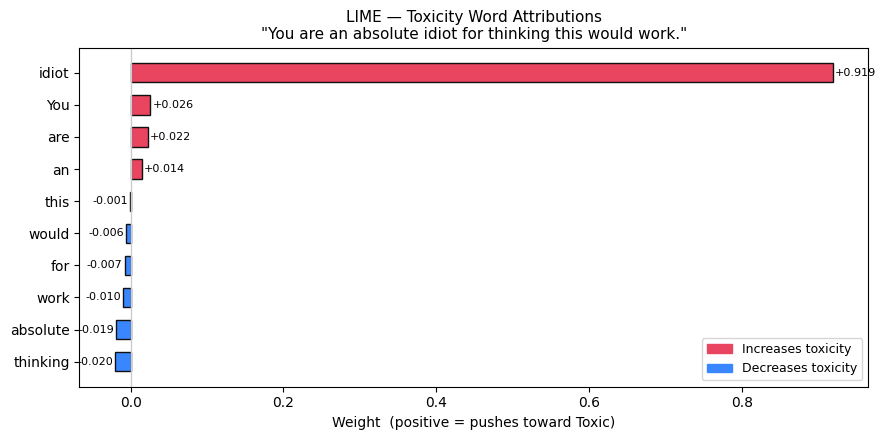

In [5]:
def visualize_lime(text, word_weights, title='LIME'):
    items   = sorted(word_weights.items(), key=lambda x:x[1])
    words   = [w for w,_ in items]
    weights = [s for _,s in items]
    colors  = ['#e94560' if w>0 else '#3a86ff' for w in weights]
    fig, ax = plt.subplots(figsize=(9, max(4,len(words)*0.45)))
    ax.barh(words, weights, color=colors, edgecolor='#111', height=0.6)
    ax.axvline(0, color='#ccc', linewidth=1)
    ax.set_title(f'{title}\n"{text[:70]}"', fontsize=11)
    ax.set_xlabel('Weight  (positive = pushes toward Toxic)')
    for i,(word,w) in enumerate(items):
        ax.text(w+(0.003 if w>=0 else -0.003), i, f'{w:+.3f}',
                va='center', ha=('left' if w>=0 else 'right'), fontsize=8)
    ax.legend(handles=[
        mpatches.Patch(color='#e94560', label='Increases toxicity'),
        mpatches.Patch(color='#3a86ff', label='Decreases toxicity'),
    ], fontsize=9)
    plt.tight_layout(); plt.show()

visualize_lime(TOXIC_TEXT, lime_weights, title='LIME — Toxicity Word Attributions')

---
## Phase 3-B — SHAP (SHapley Additive exPlanations)

**Game-theory foundation:** Each word is a "player"; the model output is the "payout".
Shapley value (phi_i) = the word's *fair average marginal contribution* across all orderings.

**Key guarantee:** Sum of all phi_i = model_output - baseline  (additive, complete)

**Partition Explainer** used here — masks token groups; much faster than exact 2^n computation.

> **SHAP vs LIME:** SHAP is more theoretically grounded; LIME is faster.
> We compare faithfulness using AOPC in Phase 3-C.


In [6]:
import shap

def shap_predict_fn(texts):
    """Returns (N, 6) probabilities for all LABEL_COLS."""
    return np.array([[get_scores(t).get(l,0) for l in LABEL_COLS] for t in texts])

masker = shap.maskers.Text(tokenizer)
shap_explainer_obj = shap.Explainer(
    shap_predict_fn, masker,
    output_names=LABEL_COLS, algorithm='partition',
)

def explain_shap(text, max_evals=200):
    return shap_explainer_obj([text], max_evals=max_evals)

def get_token_shap(sv, label='toxic'):
    idx = LABEL_COLS.index(label)
    tokens = sv.data[0]; values = sv.values[0][:, idx]
    d = {}
    for tok, val in zip(tokens, values):
        tok = tok.strip()
        if tok: d[tok] = d.get(tok,0) + float(val)
    return dict(sorted(d.items(), key=lambda x:abs(x[1]), reverse=True))

print('Computing SHAP values (~30 s)...')
shap_values = explain_shap(TOXIC_TEXT)
shap_dict   = get_token_shap(shap_values, 'toxic')

print(f'\nSHAP for: "{TOXIC_TEXT}"')
print(f"  Base value   : {shap_values.base_values[0,0]:.4f}")
print(f"  Model output : {shap_values.base_values[0,0]+shap_values.values[0,:,0].sum():.4f}\n")
print(f"  {'Token':<20} {'phi':>10}")
for tok,val in list(shap_dict.items())[:12]:
    print(f'  {tok:<20} {val:+10.4f}  {chr(9608)*int(abs(val)*60)}')

print('\nSHAP Text Plot (for toxic label):')
shap.plots.text(shap_values[0, :, 'toxic'])

Computing SHAP values (~30 s)...


  0%|          | 0/156 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:33, 33.29s/it]               


SHAP for: "You are an absolute idiot for thinking this would work."
  Base value   : 0.0018
  Model output : 0.9817

  Token                       phi
  idiot                   +0.7415  ████████████████████████████████████████████
  are                     +0.1599  █████████
  You                     +0.1266  ███████
  an                      +0.0684  ████
  for                     -0.0634  ███
  thinking                -0.0334  ██
  absolute                -0.0227  █
  would                   +0.0018  
  .                       +0.0018  
  work                    -0.0013  
  this                    +0.0008  

SHAP Text Plot (for toxic label):


---
## Phase 3-C — Faithfulness Evaluation (AOPC)

**AOPC** (Area Over the Perturbation Curve) tests whether the explanation is trustworthy:

1. Rank words by importance (most important first)
2. For k = 1...10: remove the top-k words, measure prediction drop
3. AOPC = mean(prediction_drops)

**High AOPC** → removing highlighted words actually tanks the score → faithful explanation
**Low AOPC**  → explanation highlighted unimportant words → misleading


Computing AOPC for LIME...
Computing AOPC for SHAP...

Method       AOPC   Verdict
-----------------------------------
LIME      +0.9783   
SHAP      +0.9789   More faithful


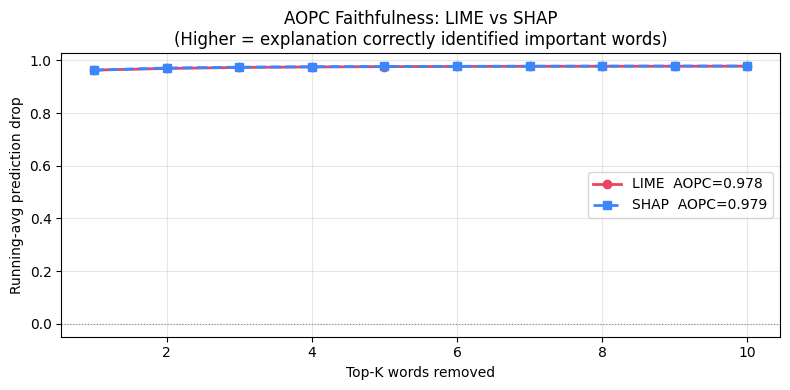

In [7]:
def compute_aopc(text, word_weights, label='toxic', max_k=10):
    s0      = get_scores(text).get(label, 0.0)
    ranked  = sorted(word_weights.items(), key=lambda x:abs(x[1]), reverse=True)
    words   = text.split()
    removed = []; drops = []
    for k in range(min(max_k, len(ranked))):
        removed.append(ranked[k][0].lower().strip(".,!?;:'\"" ))
        kept      = [w for w in words if w.lower().strip(".,!?;:'\"" ) not in removed]
        perturbed = ' '.join(kept) if kept else '[empty]'
        sk        = get_scores(perturbed).get(label, 0.0)
        drops.append(s0 - sk)
    return {'aopc': float(np.mean(drops)) if drops else 0.0,
            'orig': s0, 'drops': drops}

print('Computing AOPC for LIME...')
lime_aopc = compute_aopc(TOXIC_TEXT, lime_weights)
print('Computing AOPC for SHAP...')
shap_aopc = compute_aopc(TOXIC_TEXT, shap_dict)

wl = 'More faithful' if lime_aopc['aopc']>shap_aopc['aopc'] else ''
ws = 'More faithful' if shap_aopc['aopc']>lime_aopc['aopc'] else ''
print(f"\n{'Method':<8} {'AOPC':>8}   Verdict")
print('-'*35)
print(f"{'LIME':<8} {lime_aopc['aopc']:+8.4f}   {wl}")
print(f"{'SHAP':<8} {shap_aopc['aopc']:+8.4f}   {ws}")

fig, ax = plt.subplots(figsize=(8,4))
lc = [np.mean(lime_aopc['drops'][:i+1]) for i in range(len(lime_aopc['drops']))]
sc = [np.mean(shap_aopc['drops'][:i+1]) for i in range(len(shap_aopc['drops']))]
ax.plot(range(1,len(lc)+1), lc, 'o-', color='#e94560', lw=2, label=f"LIME  AOPC={lime_aopc['aopc']:.3f}")
ax.plot(range(1,len(sc)+1), sc, 's--', color='#3a86ff', lw=2, label=f"SHAP  AOPC={shap_aopc['aopc']:.3f}")
ax.axhline(0, color='#888', lw=0.8, ls=':')
ax.set_xlabel('Top-K words removed'); ax.set_ylabel('Running-avg prediction drop')
ax.set_title('AOPC Faithfulness: LIME vs SHAP\n(Higher = explanation correctly identified important words)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Phase 4 — Adversarial Red-Teaming

| Attack | Example | Why it fools the model |
|--------|---------|------------------------|
| Synonym | `idiot -> nincompoop` | OOV or low-frequency token |
| Leet speak | `hate -> h4t3` | Tokenizer sees unknown subwords |
| Char insert | `hate -> h-a-t-e` | Token pattern completely broken |
| Spacing | `hate -> h a t e` | Even more fragmentation |
| TextFooler | ML synonym search | Maximally semantics-preserving |

**Metric: Attack Success Rate (ASR)**  
= (# correctly detected that evade after attack) / (# correctly detected)  
Lower ASR = more robust model.


In [8]:
import re, random

SYNONYM_MAP = {
    'idiot':'nincompoop','stupid':'dim-witted','hate':'despise',
    'kill':'eliminate','die':'perish','ugly':'hideous','dumb':'vacuous',
    'trash':'rubbish','worthless':'pathetic','moron':'buffoon','jerk':'cretin',
}
LEET = {'a':'4','e':'3','i':'1','o':'0','s':'5','t':'7'}

def atk_synonym(t):  return ' '.join(SYNONYM_MAP.get(w.lower(),w) for w in t.split())
def atk_leet(t, prob=0.7): return ''.join(LEET.get(c.lower(),c) if random.random()<prob else c for c in t)
def atk_char_insert(t, ch='-'): return ' '.join(ch.join(list(w)) if len(w)>3 and w.isalpha() else w for w in t.split())
def atk_spacing(t): return ' '.join(' '.join(list(w)) if len(w)>3 else w for w in t.split())

ATTACKS = {'synonym':atk_synonym,'leet_speak':atk_leet,
           'char_insert':atk_char_insert,'spacing':atk_spacing}

TOXIC_SAMPLES = [
    'You are an absolute idiot for thinking this would work.',
    'I hope you choke on your food, you disgusting pig.',
    'This is the dumbest piece of trash I have ever read.',
    'You stupid moron, you will regret saying that.',
    'People like you are worthless and should just die.',
    'Shut up you dumb jerk, nobody asked for your opinion.',
]

results_rows = []
print(f"{'Attack':<14} {'Detected':>8} {'Evaded':>7} {'ASR':>7}")
print('-'*42)
for aname, afn in ATTACKS.items():
    detected = evaded = 0
    for text in TOXIC_SAMPLES:
        orig = get_scores(text).get('toxic',0)
        if orig < THRESHOLD: continue
        detected += 1
        pert  = afn(text)
        pscore = get_scores(pert).get('toxic',0)
        ev = pscore < THRESHOLD
        if ev: evaded += 1
        results_rows.append({'attack':aname,'text':text,'perturbed':pert,
            'orig_score':round(orig,4),'pert_score':round(pscore,4),'evaded':ev})
    asr = evaded/detected if detected else 0
    print(f'  {aname:<13} {detected:>7} {evaded:>7} {asr:>6.0%}  {chr(9608)*int(asr*30)}')
adv_df = pd.DataFrame(results_rows)

Attack         Detected  Evaded     ASR
------------------------------------------
  synonym             6       1    17%  █████
  leet_speak          6       2    33%  ██████████
  char_insert         6       0     0%  
  spacing             6       0     0%  


/tmp/ipykernel_1040/3130428942.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[g['orig_score']>=THRESHOLD]['evaded'].mean())


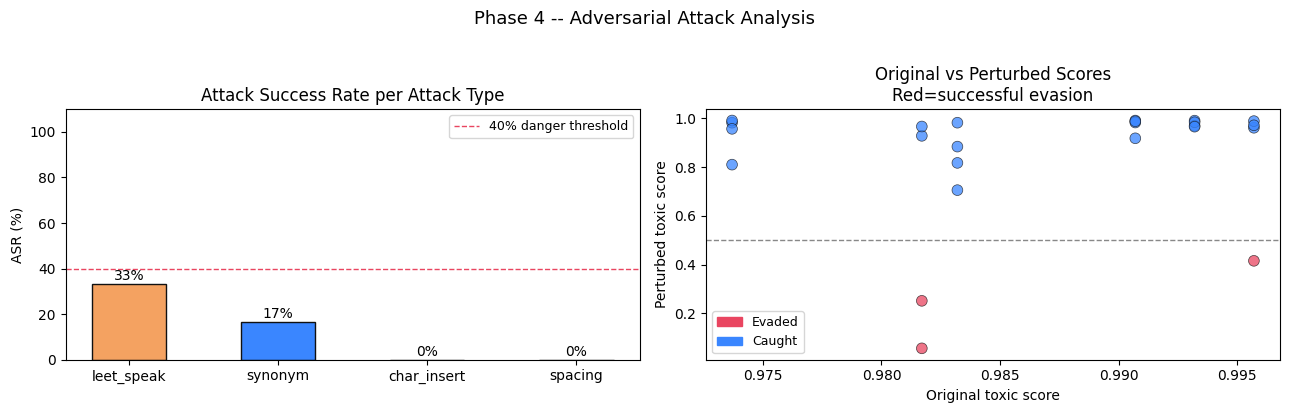

In [9]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
asr_vals = (adv_df.groupby('attack')
            .apply(lambda g: g[g['orig_score']>=THRESHOLD]['evaded'].mean())
            .sort_values(ascending=False))
colors = ['#e94560' if v>0.4 else '#f4a261' if v>0.2 else '#3a86ff' for v in asr_vals]
axes[0].bar(asr_vals.index, asr_vals*100, color=colors, edgecolor='#111', width=0.5)
axes[0].axhline(40, color='#e94560', ls='--', lw=1, label='40% danger threshold')
axes[0].set_ylabel('ASR (%)'); axes[0].set_ylim(0,110)
axes[0].set_title('Attack Success Rate per Attack Type'); axes[0].legend(fontsize=9)
for i,v in enumerate(asr_vals): axes[0].text(i,v*100+1.5,f'{v:.0%}',ha='center',fontsize=10)

axes[1].scatter(adv_df['orig_score'], adv_df['pert_score'],
                c=adv_df['evaded'].map({True:'#e94560',False:'#3a86ff'}),
                alpha=0.75, s=60, edgecolors='#111', linewidth=0.5)
axes[1].axhline(THRESHOLD, color='#888', ls='--', lw=1)
axes[1].set_xlabel('Original toxic score'); axes[1].set_ylabel('Perturbed toxic score')
axes[1].set_title('Original vs Perturbed Scores\nRed=successful evasion')
import matplotlib.patches as mp2
axes[1].legend(handles=[mp2.Patch(color='#e94560',label='Evaded'),
                         mp2.Patch(color='#3a86ff',label='Caught')],fontsize=9)
plt.suptitle('Phase 4 -- Adversarial Attack Analysis',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()

In [10]:
# TextFooler: ML-powered synonym attack
# BUG FIX from original: __call__ MUST return np.ndarray, not a Python list
import textattack

class PipelineWrapper(textattack.models.wrappers.ModelWrapper):
    def __init__(self, pipe): self.model = pipe  # .model attr required by TextAttack
    def __call__(self, text_input_list):
        out = []
        for text in text_input_list:
            p = get_scores(text).get('toxic', 0.0)
            out.append([1-p, p])
        return np.array(out, dtype=np.float32)   # MUST be ndarray, not list

model_wrapper = PipelineWrapper(classifier)
attack        = textattack.attack_recipes.TextFoolerJin2019.build(model_wrapper)

ta_data = [
    ('You are an absolute idiot for thinking this would work.', 1),
    ('I hope you choke on your food, you disgusting pig.', 1),
    ('This is the dumbest piece of trash I have ever read.', 1),
]
ta_dataset  = textattack.datasets.Dataset(ta_data)
attack_args = textattack.AttackArgs(
    num_examples=len(ta_data),
    log_to_csv='textfooler_results.csv',
    disable_stdout=False, random_seed=42,
)
attacker = textattack.Attacker(attack, ta_dataset, attack_args)
print('Running TextFooler...')
attacker.attack_dataset()
print('\nSaved -> textfooler_results.csv')

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/

Running TextFooler...
Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  WordSwapEmbedding(
    (max_candidates):  50
    (embedding):  WordEmbedding
  )
  (constraints): 
    (0): WordEmbeddingDistance(
        (embedding):  WordEmbedding
        (min_cos_sim):  0.5
        (cased):  False
        (include_unknown_words):  True
        (compare_against_original):  True
      )
    (1): PartOfSpeech(
        (tagger_type):  nltk
        (tagset):  universal
        (allow_verb_noun_swap):  True
        (compare_against_original):  True
      )
    (2): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.840845057
        (window_size):  15
        (skip_text_shorter_than_window):  True
        (compare_against_original):  False
      )
    (3): RepeatModification
    (4): StopwordModification
    (5): InputColumnModification(
        (matching_column_labels):  ['premise',

[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:  33%|███▎      | 1/3 [00:31<01:02, 31.30s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (98%)]] --> [[0 (75%)]]

You are an absolute [[idiot]] for thinking this would work.

You are an absolute [[nincompoop]] for thinking this would work.




[Succeeded / Failed / Skipped / Total] 2 / 0 / 0 / 2:  67%|██████▋   | 2/3 [00:32<00:16, 16.06s/it]

--------------------------------------------- Result 2 ---------------------------------------------
[[1 (99%)]] --> [[0 (91%)]]

[[I]] hope you [[choke]] on your food, you [[disgusting]] [[pig]].

[[me]] hope you [[muffle]] on your food, you [[detested]] [[meat]].




[Succeeded / Failed / Skipped / Total] 3 / 0 / 0 / 3: 100%|██████████| 3/3 [00:33<00:00, 11.04s/it]

--------------------------------------------- Result 3 ---------------------------------------------
[[1 (98%)]] --> [[0 (100%)]]

This is the [[dumbest]] piece of [[trash]] I have ever read.

This is the [[luckiest]] piece of [[jingles]] I have ever read.



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 3      |
| Number of failed attacks:     | 0      |
| Number of skipped attacks:    | 0      |
| Original accuracy:            | 100.0% |
| Accuracy under attack:        | 0.0%   |
| Attack success rate:          | 100.0% |
| Average perturbed word %:     | 22.73% |
| Average num. words per input: | 10.33  |
| Avg num queries:              | 80.33  |
+-------------------------------+--------+

Saved -> textfooler_results.csv


---
## Phase 5 — Human-in-the-Loop (HITL) Dashboard

The Gradio UI lets a human moderator:
1. **Analyze** text -> toxicity score + SHAP token highlights
2. **Flag False Negatives** -> model missed toxic content
3. **Flag False Positives** -> model over-flagged harmless content

All flags saved to `hitl_dataset.csv` for retraining in Phase 6.

**Confidence Zone:** 35-65% score = borderline -> human review adds the most value here.

**Fixes from original notebook:**
- Removed incorrect `color_map` from `HighlightedText` (numeric weights don't use categorical map)
- Confidence zone display added
- `_log()` correctly reads `scores_dict` as Python dict, not Gradio Label object


In [11]:
import gradio as gr

CSV_FILE  = 'hitl_dataset.csv'
CONF_LO, CONF_HI = 0.35, 0.65

if not os.path.exists(CSV_FILE):
    with open(CSV_FILE,'w',newline='',encoding='utf-8') as f:
        csv.writer(f).writerow(['text','toxic_score','zone','user_flag'])

def analyze_text(text):
    if not text.strip(): return {}, [], 'Enter some text.'
    scores = get_scores(text)
    toxic  = scores.get('toxic', 0.0)
    zone = ('HIGH confidence -- auto-flagged'    if toxic > CONF_HI else
            'LOW confidence -- auto-clean'        if toxic < CONF_LO else
            f'BORDERLINE ({CONF_LO}-{CONF_HI}) -- needs human review')
    try:
        sv   = shap_explainer_obj([text], max_evals=100)
        toks = sv.data[0]
        vals = sv.values[0][:, LABEL_COLS.index('toxic')]
        highlighted = [(str(tok), float(val)) for tok,val in zip(toks,vals)]
    except Exception:
        highlighted = [(text, 0.0)]
    label_out = {'Toxic': round(toxic,4), 'Non-Toxic': round(1-toxic,4)}
    return label_out, highlighted, zone

def _log(text, scores_dict, flag):
    # scores_dict is a plain Python dict from analyze_text return value
    toxic = scores_dict.get('Toxic', 0) if isinstance(scores_dict, dict) else 0
    zone  = 'HIGH' if toxic>CONF_HI else ('LOW' if toxic<CONF_LO else 'BORDERLINE')
    with open(CSV_FILE,'a',newline='',encoding='utf-8') as f:
        csv.writer(f).writerow([text, round(toxic,4), zone, flag])

def log_fn(text, scores):
    _log(text, scores, 'False Negative')
    return f'Logged FN | rows: {len(pd.read_csv(CSV_FILE))}'

def log_fp(text, scores):
    _log(text, scores, 'False Positive')
    return f'Logged FP | rows: {len(pd.read_csv(CSV_FILE))}'

def show_csv(_):
    try: return pd.read_csv(CSV_FILE).tail(10).to_string(index=False)
    except: return '(empty)'

with gr.Blocks(theme=gr.themes.Soft(), title='Toxicity Moderator') as demo:
    gr.Markdown('# Explainable AI -- Toxicity Moderator Dashboard')
    gr.Markdown('Analyze comments, inspect SHAP highlights, and flag model mistakes.')
    with gr.Row():
        with gr.Column(scale=1):
            text_in     = gr.Textbox(lines=4, label='Input Comment',
                                      placeholder="Try 'You are an absolute nincompoop...'")
            zone_out    = gr.Textbox(label='Confidence Zone', interactive=False)
            analyze_btn = gr.Button('Analyze', variant='primary')
            gr.Markdown('### Human Feedback')
            with gr.Row():
                fn_btn = gr.Button('Flag: False Negative', variant='stop')
                fp_btn = gr.Button('Flag: False Positive',  variant='secondary')
            log_out = gr.Textbox(label='Log Status', interactive=False)
        with gr.Column(scale=1):
            score_out = gr.Label(label='Toxicity Confidence')
            shap_out  = gr.HighlightedText(
                label='SHAP Attribution (Red=toxic driver, Blue=non-toxic driver)',
                combine_adjacent=True, show_legend=True,
            )
            view_btn = gr.Button('Show last 10 logged entries')
            csv_out  = gr.Textbox(label='HITL Dataset Preview', lines=10, interactive=False)
    analyze_btn.click(analyze_text, inputs=text_in, outputs=[score_out, shap_out, zone_out])
    fn_btn.click(log_fn, inputs=[text_in, score_out], outputs=log_out)
    fp_btn.click(log_fp, inputs=[text_in, score_out], outputs=log_out)
    view_btn.click(show_csv, inputs=view_btn, outputs=csv_out)

demo.launch(share=True)

/tmp/ipykernel_1040/447875459.py:46: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title='Toxicity Moderator') as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56196b532f50153784.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Phase 6 — Robust Fine-Tuning

We combine three data sources:

| Source | Content | Label |
|--------|---------|-------|
| `hitl_dataset.csv` | Human-flagged FN/FP | Human-corrected binary |
| `textfooler_results.csv` | ML adversarial evasions | 1 (toxic) |
| Dummy injections | Leet-speak and implicit hate | 1 (toxic) |

**Critical bug fixed from original:**  
The original notebook built `hf_dataset` from `hitl_df` only, then created `combined_df` but  
never reassigned `hf_dataset = Dataset.from_pandas(combined_df)`. The Trainer silently  
trained on HITL data alone, completely ignoring TextFooler and ToxiGen data.

**Other fixes:** weighted BCE loss, eval_strategy with F1 tracking, dynamic checkpoint loading.


In [12]:
DUMMY = [
    ('Y0u are a c0mplete m0r0n.', 1),
    ('People from your city are all cr1m1nals.', 1),
    ('I w1ll end you if you say that again.', 1),
    ('h-a-t-e f-i-l-l-s m-e w-h-e-n I s-e-e y-o-u.', 1),
    ('What a brilliantly stupid idea.', 0),
]
with open(CSV_FILE,'a',newline='',encoding='utf-8') as f:
    writer = csv.writer(f)
    for text, lbl in DUMMY:
        flag = 'False Negative (dummy)' if lbl else 'False Positive (dummy)'
        writer.writerow([text, 0.15, 'BORDERLINE', flag])
print(f'Injected {len(DUMMY)} dummy examples. Total: {len(pd.read_csv(CSV_FILE))} rows')

Injected 5 dummy examples. Total: 5 rows


In [13]:
import torch.nn as nn
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                           Trainer, TrainingArguments)
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score

# 1. HITL data
hitl_df = pd.read_csv(CSV_FILE)
hitl_df['label'] = hitl_df['user_flag'].apply(
    lambda f: 1 if 'False Negative' in str(f) else 0)
hitl_clean = hitl_df[['text','label']].dropna().copy()

# 2. TextFooler successful attacks
ta_clean = pd.DataFrame(columns=['text','label'])
try:
    ta_df = pd.read_csv('textfooler_results.csv')
    succ  = ta_df[ta_df['result_type']=='Successful'].copy()
    ta_clean = succ[['perturbed_text']].rename(columns={'perturbed_text':'text'})
    ta_clean['label'] = 1
    print(f'TextFooler: {len(ta_clean)} successful adversarial examples')
except FileNotFoundError:
    print('textfooler_results.csv not found -- run Phase 4 TextFooler cell first')

# 3. Combine and shuffle
combined = pd.concat([hitl_clean, ta_clean], ignore_index=True).dropna()
combined = combined.sample(frac=1, random_state=42).reset_index(drop=True)
n_pos = combined['label'].sum(); n_neg = len(combined)-n_pos
pos_weight = n_neg/n_pos if n_pos>0 else 1.0
print(f'Combined: {len(combined)} samples | Toxic:{n_pos} Non-toxic:{n_neg} pos_weight:{pos_weight:.2f}')

TextFooler: 3 successful adversarial examples
Combined: 8 samples | Toxic:7 Non-toxic:1 pos_weight:0.14


In [14]:
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# BUG FIX: rebuild hf_dataset from combined DataFrame
hf_ds = Dataset.from_pandas(combined[['text','label']])

def tokenize_fn(ex):
    return ft_tokenizer(ex['text'], padding='max_length', truncation=True, max_length=128)

hf_ds = hf_ds.map(tokenize_fn, batched=True)
hf_ds = hf_ds.rename_column('label','labels')
hf_ds.set_format('torch', columns=['input_ids','attention_mask','labels'])
split = hf_ds.train_test_split(test_size=0.2, seed=42)
train_ds, eval_ds = split['train'], split['test']
print(f'Train: {len(train_ds)} | Eval: {len(eval_ds)}')

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Train: 6 | Eval: 2


In [15]:
class WeightedTrainer(Trainer):
    """Custom Trainer injecting pos_weight into BCE loss for imbalanced data."""
    def __init__(self, *args, pos_weight=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._pos_weight = pos_weight
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels').float()
        outputs = model(**inputs)
        logits  = outputs.logits[:, 1]
        pw      = torch.tensor([self._pos_weight], device=logits.device)
        loss    = nn.BCEWithLogitsLoss(pos_weight=pw)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'f1':f1_score(labels,preds,zero_division=0),
            'accuracy':accuracy_score(labels,preds)}

ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True,
    problem_type='single_label_classification')

training_args = TrainingArguments(
    output_dir              = './robust_toxic_model',
    num_train_epochs        = 5,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 8,
    learning_rate           = 2e-5,
    weight_decay            = 0.01,
    eval_strategy           = 'epoch',
    save_strategy           = 'epoch',
    load_best_model_at_end  = True,
    metric_for_best_model   = 'f1',
    logging_steps           = 5,
    report_to               = 'none',
)

trainer = WeightedTrainer(
    model=ft_model, args=training_args,
    train_dataset=train_ds, eval_dataset=eval_ds,
    compute_metrics=compute_metrics, pos_weight=pos_weight,
)
print('Starting fine-tuning with weighted BCE loss...')
trainer.train()
print('Fine-tuning complete! Best model -> ./robust_toxic_model')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unitary/toxic-bert and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([6]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([6, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting fine-tuning with weighted BCE loss...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,No log,0.124848,0.000000,0.000000
2,No log,0.122691,0.000000,0.000000
3,0.183200,0.121985,0.000000,0.000000
4,0.183200,0.121360,0.000000,0.000000
5,0.175900,0.121198,0.000000,0.000000


Fine-tuning complete! Best model -> ./robust_toxic_model


---
## Phase 7 — Final Evaluation: Baseline vs Hardened Model

**Fix from original:**
Hardcoded `checkpoint-15` path replaced with dynamic discovery of the latest checkpoint.


In [16]:
import glob

ckpts = sorted(glob.glob('./robust_toxic_model/checkpoint-*'), key=os.path.getmtime)
if not ckpts:
    raise FileNotFoundError('No checkpoint found. Run Phase 6 first.')
best_ckpt = ckpts[-1]
print(f'Loading checkpoint: {best_ckpt}')

hard_model = AutoModelForSequenceClassification.from_pretrained(best_ckpt)
hard_tok   = AutoTokenizer.from_pretrained(MODEL_NAME)
hard_pipe  = pipeline('text-classification', model=hard_model, tokenizer=hard_tok,
                       device=DEVICE, return_all_scores=True)

def hard_score(text):
    res = hard_pipe(text)[0]
    for item in res:
        if item['label'] in ('LABEL_1','toxic'): return item['score']
    return max(r['score'] for r in res)

print('Hardened model loaded.')

Loading checkpoint: ./robust_toxic_model/checkpoint-10


Device set to use cuda:0


Hardened model loaded.


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [17]:
EVAL_CASES = [
    ('Original toxic',   'You are an absolute idiot for thinking this would work.'),
    ('Synonym attack',   'You are an absolute nincompoop for thinking this would work.'),
    ('Leet speak',       'Y0u are an abs0lute 1d10t f0r th1nk1ng th1s w0uld w0rk.'),
    ('Char insert',      'Y-o-u a-r-e a-n i-d-i-o-t.'),
    ('Spacing',          'h a t e f i l l s m e'),
    ('Clean control',    'I completely disagree with your thoughtful assessment.'),
    ('Implicit hate',    'People from that background always cause trouble.'),
]

print(f"{'Type':<22} {'Baseline':>10} {'Hardened':>10}  Verdict")
print('-'*70)
base_s, hard_s = [], []
for lbl, text in EVAL_CASES:
    b = get_scores(text).get('toxic', 0.0)
    h = hard_score(text)
    base_s.append(b); hard_s.append(h)
    if 'Clean' in lbl:
        verdict = 'Both clean' if h<0.5 else 'FP by hardened'
    else:
        verdict = f"Base:{'FLAGGED' if b>0.5 else 'MISSED'}  Hard:{'FLAGGED' if h>0.5 else 'MISSED'}"
    print(f'  {lbl:<20} {b:10.4f} {h:10.4f}  {verdict}')

Type                     Baseline   Hardened  Verdict
----------------------------------------------------------------------
  Original toxic           0.9817     0.5745  Base:FLAGGED  Hard:FLAGGED
  Synonym attack           0.2512     0.6325  Base:MISSED  Hard:FLAGGED
  Leet speak               0.9483     0.6553  Base:FLAGGED  Hard:FLAGGED
  Char insert              0.9115     0.6441  Base:FLAGGED  Hard:FLAGGED
  Spacing                  0.4800     0.5905  Base:MISSED  Hard:FLAGGED
  Clean control            0.0006     0.3676  Both clean
  Implicit hate            0.0010     0.3889  Base:MISSED  Hard:MISSED


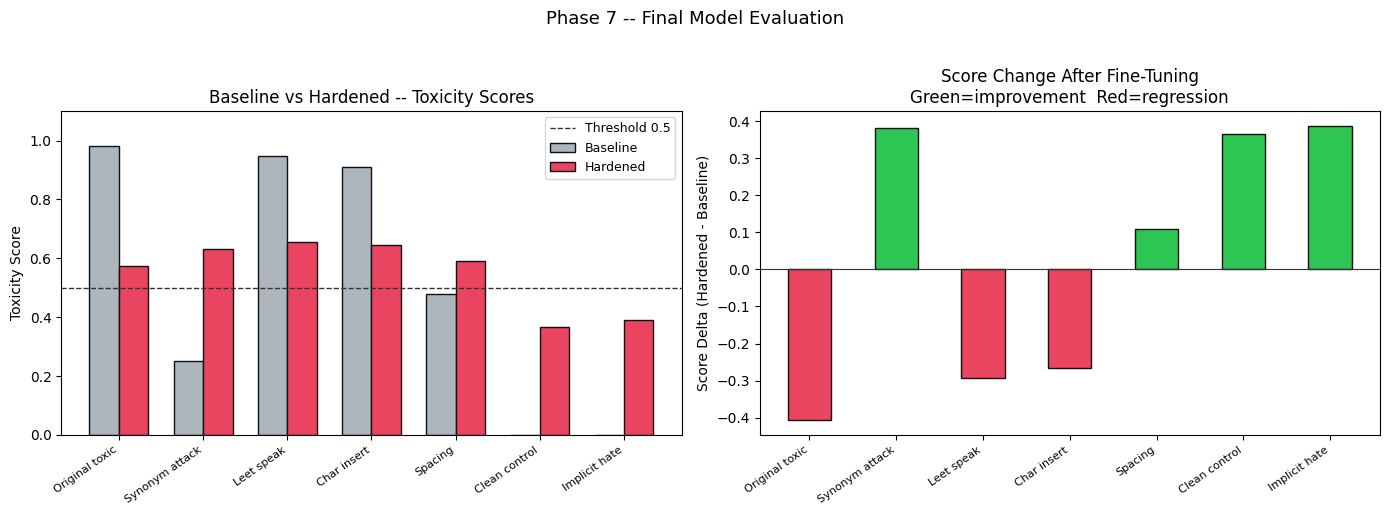

In [18]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
labels_s=[l for l,_ in EVAL_CASES]; x=list(range(len(EVAL_CASES))); w=0.35
axes[0].bar([i-w/2 for i in x],base_s,w,label='Baseline',color='#adb5bd',edgecolor='#111')
axes[0].bar([i+w/2 for i in x],hard_s,w,label='Hardened',color='#e94560',edgecolor='#111')
axes[0].axhline(0.5,color='#333',ls='--',lw=1,label='Threshold 0.5')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_s,rotation=35,ha='right',fontsize=8)
axes[0].set_ylabel('Toxicity Score'); axes[0].set_ylim(0,1.1)
axes[0].set_title('Baseline vs Hardened -- Toxicity Scores'); axes[0].legend(fontsize=9)

deltas=[h-b for b,h in zip(base_s,hard_s)]
axes[1].bar(x,deltas,color=['#2dc653' if d>0 else '#e94560' for d in deltas],edgecolor='#111',width=0.5)
axes[1].axhline(0,color='#333',lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_s,rotation=35,ha='right',fontsize=8)
axes[1].set_ylabel('Score Delta (Hardened - Baseline)')
axes[1].set_title('Score Change After Fine-Tuning\nGreen=improvement  Red=regression')
plt.suptitle('Phase 7 -- Final Model Evaluation',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()

In [19]:
print('ASR Re-evaluation: Baseline vs Hardened\n')
print(f"  {'Attack':<14} {'Base ASR':>10} {'Hard ASR':>10}  Change")
print('  '+'-'*48)
for aname, afn in ATTACKS.items():
    b_ev=h_ev=total=0
    for text in TOXIC_SAMPLES:
        if get_scores(text).get('toxic',0)<THRESHOLD: continue
        total+=1
        pert=afn(text)
        if get_scores(pert).get('toxic',0)<THRESHOLD: b_ev+=1
        if hard_score(pert)<THRESHOLD:               h_ev+=1
    b_asr=b_ev/total if total else 0
    h_asr=h_ev/total if total else 0
    delta=b_asr-h_asr
    sign='improved' if delta>0 else ('same' if delta==0 else 'worse')
    print(f'  {aname:<14} {b_asr:>9.0%} {h_asr:>10.0%}  {sign} ({delta:+.0%})')

ASR Re-evaluation: Baseline vs Hardened

  Attack           Base ASR   Hard ASR  Change
  ------------------------------------------------
  synonym              17%         0%  improved (+17%)
  leet_speak           33%         0%  improved (+33%)
  char_insert           0%         0%  same (+0%)
  spacing               0%         0%  same (+0%)


---
## Summary -- Responsible AI Coverage

| Pillar | Implementation | Phase |
|--------|---------------|-------|
| **Transparency** | LIME word weights + SHAP token attributions | 3-A, 3-B |
| **Faithfulness** | AOPC metric -- quantifies XAI trustworthiness | 3-C |
| **Fairness** | Weighted BCE loss for class imbalance | 6 |
| **Robustness** | 4 custom attacks + TextFooler + ASR metric | 4 |
| **Accountability** | HITL dashboard with confidence zone + logging | 5 |
| **Continuous learning** | Combined HITL + adversarial retraining | 6 |

### Key Discussion Points for Your Report
1. **AOPC comparison** -- is LIME or SHAP more faithful to the model?
2. **Which attack had the highest ASR?** -- vocabulary generalization vs token structure
3. **Did fine-tuning reduce ASR?** -- by how much per attack type?
4. **Automation bias risk** -- could SHAP highlights cause reviewers to trust wrong predictions?
5. **Confidence zone analysis** -- what percentage of comments fall in the borderline 35-65% zone?
